#**Delhivery - Feature Engineering**

#Problem Statement

Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.

The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency, and profitability of their business versus their competitors.

The company wants to understand and process the data coming out of data engineering pipelines:

• Clean, sanitize and manipulate data to get useful features out of raw fields

• Make sense out of the raw data and help the data science team to build forecasting models on it

#Importing Data and Python Libraries

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel

from sklearn.preprocessing import StandardScaler

In [80]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181 -O final.csv

--2026-05-27 13:06:58--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 108.157.172.176, 108.157.172.10, 108.157.172.183, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|108.157.172.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55617130 (53M) [text/plain]
Saving to: ‘final.csv’

final.csv           100%[===================>]  53.04M   175MB/s    in 0.3s    

2026-05-27 13:06:58 (175 MB/s) - ‘final.csv’ saved [55617130/55617130]



In [81]:
df = pd.read_csv('/content/final.csv')

In [82]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [83]:
df.shape

(144867, 24)

**Observation:**

The dataset contains 144867 rows and 24 columns, indicating a large shipment-level logistics dataset with multiple operational variables.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

**Observation:**

The dataset contains 144867 records and 24 columns consisting of categorical, numerical, boolean, and datetime-related features.

Most columns do not contain missing values. However, source_name and destination_name contain a small number of null values, which will require treatment during data cleaning.

The dataset also contains multiple object-type columns that can later be optimized into categorical and datetime formats for improved memory efficiency and analysis.

In [85]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


**Observation:**

Several numerical variables such as actual_time, osrm_time, and osrm_distance show large standard deviations and wide ranges between minimum and maximum values.

The presence of extremely high maximum values compared to median values indicates potential outliers and right-skewed distributions in operational delivery metrics.

Negative values observed in segment_actual_time and segment_factor may indicate data inconsistencies or exceptional operational cases that require further investigation.

In [86]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


**Observation:**

Missing values are present only in source_name and destination_name columns, with 293 and 261 missing entries respectively.

Since the proportion of missing values is extremely small compared to the overall dataset size, these values can be treated without causing major information loss.

The remaining columns do not contain any missing values, indicating strong overall data completeness.

In [87]:
df.duplicated().sum()

np.int64(0)

**Observation:**

No duplicate rows were found in the dataset, indicating that each shipment-segment record is uniquely captured.

# Data Type Conversion

Convert datetime columns

In [88]:
datetime_cols = [
    'trip_creation_time',
    'od_start_time',
    'od_end_time'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

Convert categorical columns

In [89]:
cat_cols = ['data','route_type']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [90]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  category      
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  category      
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

**Observation:**

Datetime and categorical conversions improve memory efficiency and simplify temporal and categorical analysis in later stages of the project.

Dropping Unknown or Irrelevant Features

In [91]:
unknown_cols = [
    'is_cutoff',
    'cutoff_factor',
    'cutoff_timestamp',
    'factor',
    'segment_factor'
]

df.drop(columns=unknown_cols, inplace=True)

In [92]:
df.shape

(144867, 19)

**Observation:**

Columns with unclear business meaning or limited interpretability were removed to improve analytical clarity and reduce unnecessary complexity.

Missing Value Treatment

In [93]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


Create mapping for source names

In [94]:
source_mapping = (
    df.groupby('source_center')['source_name']
    .first()
)

Create mapping for destination names

In [95]:
destination_mapping = (
    df.groupby('destination_center')['destination_name']
    .first()
)

Fill missing source names

In [96]:
df['source_name'] = df['source_name'].fillna(
    df['source_center'].map(source_mapping)
)

Fill missing destination names

In [97]:
df['destination_name'] = df['destination_name'].fillna(
    df['destination_center'].map(destination_mapping)
)

Remaining nulls

In [98]:
df['source_name'] = df['source_name'].fillna('Unknown')
df['destination_name'] = df['destination_name'].fillna('Unknown')

In [99]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,0
destination_center,0
destination_name,0
od_start_time,0


**Observation:**

Missing location names were treated using center-based mapping to preserve business consistency and minimize information loss.

# Feature Engineering from Location Data

Extracting Source & Destination of State

In [100]:
df['source_state'] = df['source_name'].str.extract(r'\((.*)\)')

In [101]:
df['destination_state'] = df['destination_name'].str.extract(r'\((.*)\)')

Extracting Source & Destination of City

In [102]:
df['source_city'] = df['source_name'].str.split('_').str[0]

In [103]:
df['destination_city'] = df['destination_name'].str.split('_').str[0]

In [104]:
df[['source_name',
    'source_city',
    'source_state']].head()

,source_name,source_city,source_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
3,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
4,Anand_VUNagar_DC (Gujarat),Anand,Gujarat


**Observation:**

City and state-level features were extracted from shipment location names to enable corridor-level and regional logistics analysis.

# Time-Based Feature Engineering

In [105]:
df['trip_month'] = df['trip_creation_time'].dt.month

In [106]:
df['trip_day'] = df['trip_creation_time'].dt.day

In [107]:
df['trip_hour'] = df['trip_creation_time'].dt.hour

In [108]:
df['trip_weekday'] = (
    df['trip_creation_time']
    .dt.day_name()
)

In [109]:
df[['trip_creation_time',
    'trip_month',
    'trip_day',
    'trip_hour',
    'trip_weekday']].head()

,trip_creation_time,trip_month,trip_day,trip_hour,trip_weekday
0,2018-09-20 02:35:36.476840,9,20,2,Thursday
1,2018-09-20 02:35:36.476840,9,20,2,Thursday
2,2018-09-20 02:35:36.476840,9,20,2,Thursday
3,2018-09-20 02:35:36.476840,9,20,2,Thursday
4,2018-09-20 02:35:36.476840,9,20,2,Thursday


**Observation:**

Temporal features such as month, day, hour, and weekday were extracted to analyze operational delivery patterns across different time periods.

# Trip Duration Feature

In [110]:
df['od_time_diff'] = (
    df['od_end_time'] -
    df['od_start_time']
).dt.total_seconds()/60

In [111]:
df[['od_start_time',
    'od_end_time',
    'od_time_diff']].head()

,od_start_time,od_end_time,od_time_diff
0,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
1,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
2,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
3,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
4,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637


**Observation:**

A new feature representing total trip duration in minutes was created using origin-destination timestamps.

# Understanding Shipment Segmentation

Each trip in the dataset is divided into multiple shipment segments. Therefore, multiple rows may belong to the same trip.

To perform meaningful operational analysis, shipment-segment records must be aggregated into trip-level records by combining cumulative metrics while preserving key identifying information.

# Aggregating Shipment Segments

In [112]:
group_cols = [
    'trip_uuid',
    'source_center',
    'destination_center'
]

In [113]:
agg_dict = {

    'actual_time':'last',
    'osrm_time':'last',
    'osrm_distance':'last',

    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',

    'trip_creation_time':'first',
    'route_type':'first',

    'source_name':'first',
    'destination_name':'last',

    'source_state':'first',
    'destination_state':'last',

    'source_city':'first',
    'destination_city':'last',

    'od_start_time':'first',
    'od_end_time':'last',

    'start_scan_to_end_scan':'first',

    'od_time_diff':'first'
}

In [114]:
df_grouped = (
    df.groupby(group_cols)
    .agg(agg_dict)
    .reset_index()
)

In [115]:
df_grouped.shape

(26368, 21)

In [116]:
df_grouped.head()

,trip_uuid,source_center,destination_center,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,trip_creation_time,...,source_name,destination_name,source_state,destination_state,source_city,destination_city,od_start_time,od_end_time,start_scan_to_end_scan,od_time_diff
0,trip-153671041653548748,IND209304AAA,IND000000ACB,732.0,329.0,446.5496,728.0,534.0,670.6205,2018-09-12 00:00:16.535741,...,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Uttar Pradesh,Haryana,Kanpur,Gurgaon,2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,1260.0,1260.604421
1,trip-153671041653548748,IND462022AAA,IND209304AAA,830.0,388.0,544.8027,820.0,474.0,649.8528,2018-09-12 00:00:16.535741,...,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Madhya Pradesh,Uttar Pradesh,Bhopal,Kanpur,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,999.0,999.505379
2,trip-153671042288605164,IND561203AAB,IND562101AAA,47.0,26.0,28.1994,46.0,26.0,28.1995,2018-09-12 00:00:22.886430,...,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Karnataka,Karnataka,Doddablpur,Chikblapur,2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,58.0,58.832388
3,trip-153671042288605164,IND572101AAA,IND561203AAB,96.0,42.0,56.9116,95.0,39.0,55.9899,2018-09-12 00:00:22.886430,...,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Karnataka,Karnataka,Tumkur,Doddablpur,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,122.0,122.779486
4,trip-153671043369099517,IND000000ACB,IND160002AAC,611.0,212.0,281.2109,608.0,231.0,317.7408,2018-09-12 00:00:33.691250,...,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),Haryana,Punjab,Gurgaon,Chandigarh,2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,834.0,834.638929


**Observation:**

Shipment-segment records were aggregated into route-level operational records by summing cumulative metrics and preserving identifying trip information.

# Trip-Level Aggregation

In [117]:
trip_agg = {

    'actual_time':'sum',
    'osrm_time':'sum',
    'osrm_distance':'sum',

    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',

    'start_scan_to_end_scan':'sum',
    'od_time_diff':'sum',

    'trip_creation_time':'first',
    'route_type':'first',

    'source_name':'first',
    'destination_name':'last',

    'source_state':'first',
    'destination_state':'last',

    'source_city':'first',
    'destination_city':'last'
}

In [118]:
trip_df = (
    df_grouped.groupby('trip_uuid')
    .agg(trip_agg)
    .reset_index()
)

In [119]:
trip_df.shape

(14817, 17)

In [120]:
trip_df.head()

,trip_uuid,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,start_scan_to_end_scan,od_time_diff,trip_creation_time,route_type,source_name,destination_name,source_state,destination_state,source_city,destination_city
0,trip-153671041653548748,1562.0,717.0,991.3523,1548.0,1008.0,1320.4733,2259.0,2260.109800,2018-09-12 00:00:16.535741,FTL,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Uttar Pradesh,Uttar Pradesh,Kanpur,Kanpur
1,trip-153671042288605164,143.0,68.0,85.1110,141.0,65.0,84.1894,180.0,181.611874,2018-09-12 00:00:22.886430,Carting,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Karnataka,Karnataka,Doddablpur,Doddablpur
2,trip-153671043369099517,3347.0,1740.0,2354.0665,3308.0,1941.0,2545.2678,3933.0,3934.362520,2018-09-12 00:00:33.691250,FTL,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),Haryana,Haryana,Gurgaon,Gurgaon
3,trip-153671046011330457,59.0,15.0,19.6800,59.0,16.0,19.8766,100.0,100.494935,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Maharashtra,Maharashtra,Mumbai Hub (Maharashtra),Mumbai
4,trip-153671052974046625,341.0,117.0,146.7918,340.0,115.0,146.7919,717.0,718.349042,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),Karnataka,Karnataka,Bellary,Sandur


**Observation:**

Route-level shipment records were further aggregated into trip-level operational records to enable complete end-to-end logistics analysis.

# Delivery Performance Feature Engineering

Time Difference Feature

In [121]:
trip_df['time_difference'] = (
    trip_df['actual_time'] -
    trip_df['osrm_time']
)

Delay Ratio Feature

In [122]:
trip_df['delay_ratio'] = (
    trip_df['actual_time'] /
    trip_df['osrm_time']
)

Actual Speed

In [123]:
trip_df['actual_speed'] = (
    trip_df['osrm_distance'] /
    (trip_df['actual_time']/60)
)

OSRM Speed

In [124]:
trip_df['osrm_speed'] = (
    trip_df['osrm_distance'] /
    (trip_df['osrm_time']/60)
)

In [125]:
trip_df[[
    'actual_time',
    'osrm_time',
    'time_difference',
    'delay_ratio',
    'actual_speed',
    'osrm_speed'
]].head()

,actual_time,osrm_time,time_difference,delay_ratio,actual_speed,osrm_speed
0,1562.0,717.0,845.0,2.178522,38.080114,82.958351
1,143.0,68.0,75.0,2.102941,35.710909,75.097941
2,3347.0,1740.0,1607.0,1.923563,42.200176,81.174707
3,59.0,15.0,44.0,3.933333,20.013559,78.720000
4,341.0,117.0,224.0,2.914530,25.828469,75.277846


**Observation:**

Additional delivery performance features were created to evaluate operational delays, estimated-versus-actual delivery efficiency, and average transportation speeds across trips.

# Univariate Analysis

1. Distribution Plot - Actual Time

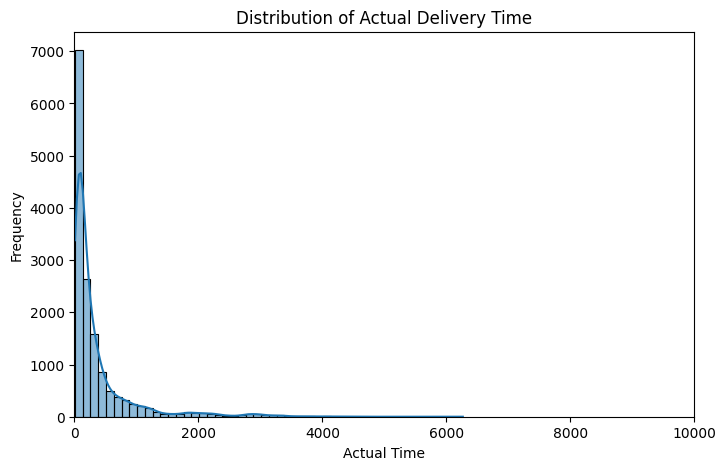

In [127]:
plt.figure(figsize=(8,5))

sns.histplot(
    trip_df['actual_time'],
    kde=True,
    bins=50
)

plt.xlim(0, 10000)

plt.title('Distribution of Actual Delivery Time')
plt.xlabel('Actual Time')
plt.ylabel('Frequency')

plt.show()

**Observation:**

The distribution of actual delivery time appears right-skewed, with most deliveries concentrated at lower durations and a small number of extremely long trips indicating potential outliers.

2. Distribution of OSRM Estimated Time

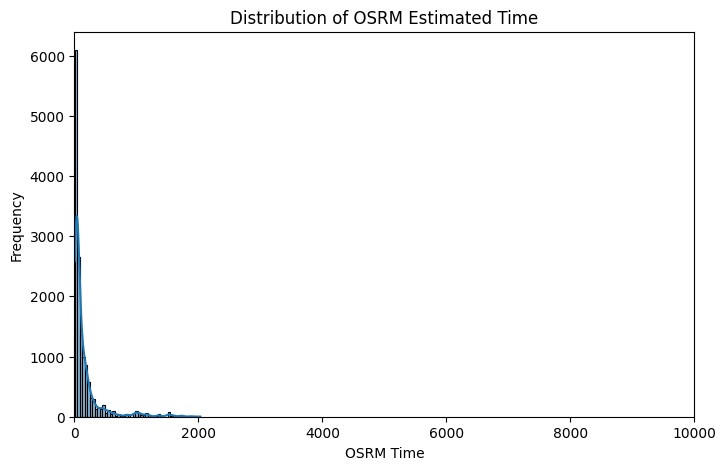

In [128]:
plt.figure(figsize=(8,5))

sns.histplot(
    trip_df['osrm_time'],
    kde=True,
    bins=50
)

plt.xlim(0, 10000)

plt.title('Distribution of OSRM Estimated Time')
plt.xlabel('OSRM Time')
plt.ylabel('Frequency')

plt.show()

**Observation:**

OSRM estimated delivery times also show a right-skewed distribution, indicating that most routes are relatively short while a few extremely long-distance trips exist.

3. Distribution of OSRM Distance

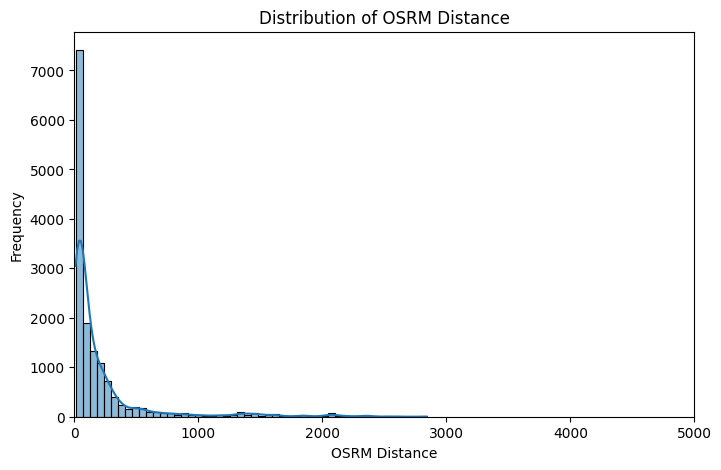

In [129]:
plt.figure(figsize=(8,5))

sns.histplot(
    trip_df['osrm_distance'],
    kde=True,
    bins=50
)

plt.xlim(0, 5000)

plt.title('Distribution of OSRM Distance')
plt.xlabel('OSRM Distance')
plt.ylabel('Frequency')

plt.show()

**Observation:**

Most delivery trips cover shorter distances, while a smaller number of trips span significantly larger delivery corridors, resulting in a positively skewed distribution.

4. Distribution of Segment Actual Time

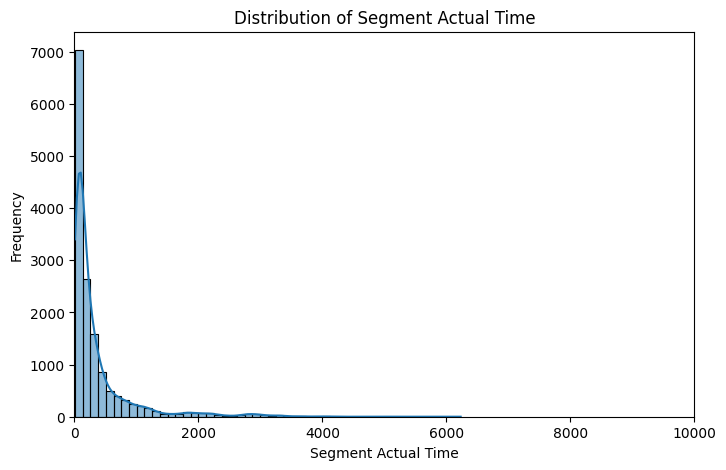

In [130]:
plt.figure(figsize=(8,5))

sns.histplot(
    trip_df['segment_actual_time'],
    kde=True,
    bins=50
)

plt.xlim(0, 10000)

plt.title('Distribution of Segment Actual Time')
plt.xlabel('Segment Actual Time')
plt.ylabel('Frequency')

plt.show()

**Observation:**

Segment-level delivery times are concentrated around lower values, but several extreme operational segments contribute to a heavily right-skewed distribution.

# Outlier Analysis

1. Boxplot - Actual Time

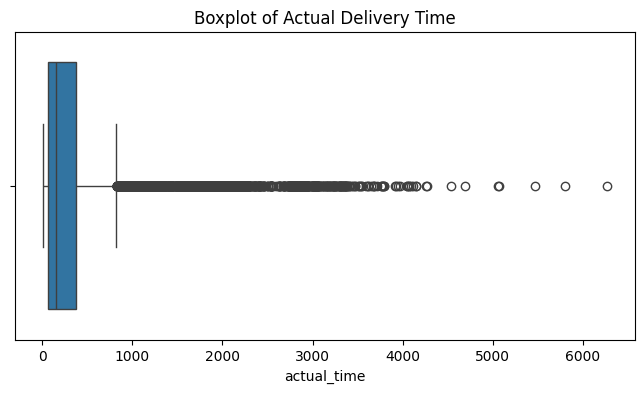

In [131]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df['actual_time']
)

plt.title('Boxplot of Actual Delivery Time')

plt.show()

2. Boxplot — OSRM Time

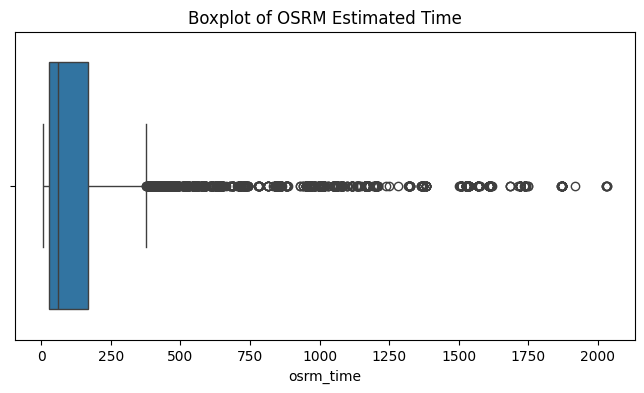

In [132]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df['osrm_time']
)

plt.title('Boxplot of OSRM Estimated Time')

plt.show()

3. Boxplot — OSRM Distance

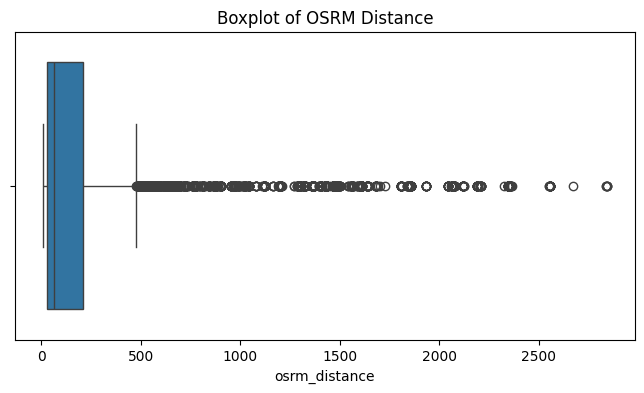

In [133]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df['osrm_distance']
)

plt.title('Boxplot of OSRM Distance')

plt.show()

4. Boxplot — Actual Speed

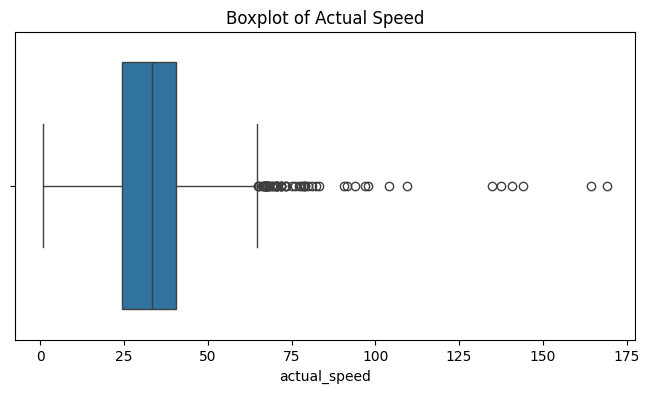

In [134]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df['actual_speed']
)

plt.title('Boxplot of Actual Speed')

plt.show()

**Observation:**

Several numerical features contain extreme values outside the interquartile range, indicating the presence of operational outliers and unusually delayed or exceptionally long delivery trips.

# Bivariate Analysis

1. Scatterplot — Actual Time vs OSRM Time

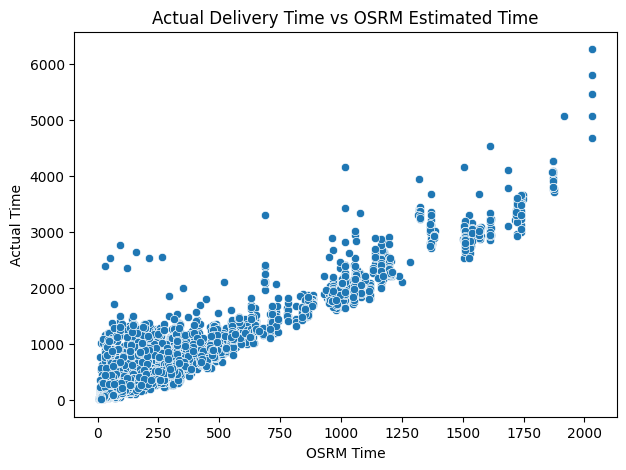

In [135]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='osrm_time',
    y='actual_time',
    data=trip_df
)

plt.title('Actual Delivery Time vs OSRM Estimated Time')

plt.xlabel('OSRM Time')
plt.ylabel('Actual Time')

plt.show()

**Observation:**

Actual delivery time shows a strong positive relationship with OSRM estimated time. However, actual delivery durations are generally higher than estimated values, indicating operational inefficiencies and delays.

2. Scatterplot — OSRM Distance vs Actual Time

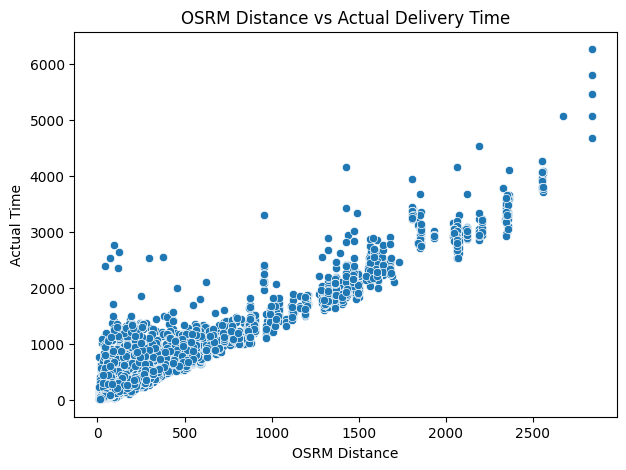

In [136]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='osrm_distance',
    y='actual_time',
    data=trip_df
)

plt.title('OSRM Distance vs Actual Delivery Time')

plt.xlabel('OSRM Distance')
plt.ylabel('Actual Time')

plt.show()

**Observation:**

Longer travel distances generally correspond to higher delivery durations, confirming a positive operational relationship between route distance and delivery time.

# Correlation Analysis

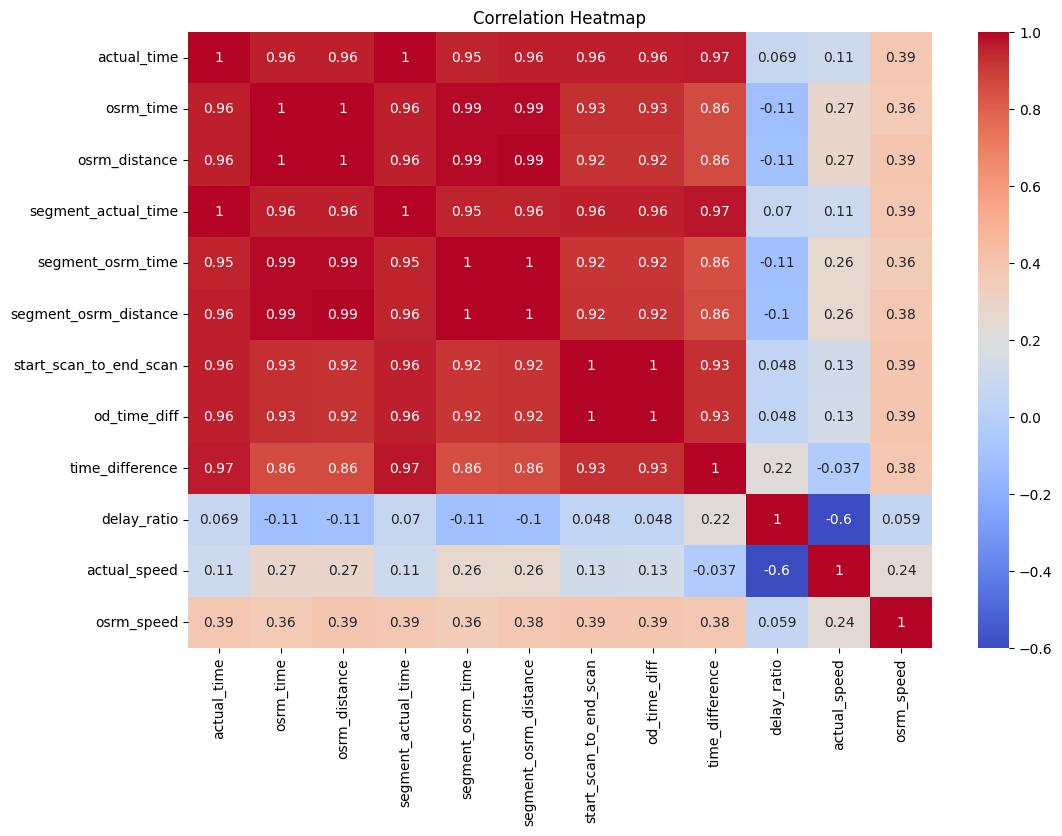

In [137]:
plt.figure(figsize=(12,8))

corr = trip_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Observation:**

Strong positive correlations exist between actual_time, osrm_time, osrm_distance, and segment-level operational metrics. This indicates that longer routes naturally require higher delivery durations and segment times.

# Hypothesis Testing

1. Actual Delivery Time vs OSRM Estimated Time

Null Hypothesis (H0):

There is no significant difference between actual delivery time and OSRM estimated delivery time.

Alternate Hypothesis (H1):

There is a significant difference between actual delivery time and OSRM estimated delivery time.

In [138]:
from scipy.stats import ttest_rel

stat, p_value = ttest_rel(
    trip_df['actual_time'],
    trip_df['osrm_time']
)

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 76.61411942262393
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between actual delivery time and OSRM estimated delivery time. The result suggests that real-world delivery operations differ considerably from route-based estimated delivery times, likely due to traffic conditions, operational delays, and logistical inefficiencies.

2. Actual Delivery Time vs Segment Actual Time

Null Hypothesis (H0):

There is no significant difference between aggregated actual delivery time and aggregated segment actual time.

Alternate Hypothesis (H1):

There is a significant difference between aggregated actual delivery time and aggregated segment actual time.

In [139]:
stat, p_value = ttest_rel(
    trip_df['actual_time'],
    trip_df['segment_actual_time']
)

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 68.46429609754104
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated actual delivery time and aggregated segment actual time. The result suggests that operational variations exist across delivery segments and overall trip execution.

3. OSRM Distance vs Segment OSRM Distance

Null Hypothesis (H0):

There is no significant difference between aggregated OSRM distance and aggregated segment OSRM distance.

Alternate Hypothesis (H1):

There is a significant difference between aggregated OSRM distance and aggregated segment OSRM distance.

In [140]:
stat, p_value = ttest_rel(
    trip_df['osrm_distance'],
    trip_df['segment_osrm_distance']
)

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: -37.381312117726914
P-value: 2.419297272724162e-292


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated OSRM distance and aggregated segment OSRM distance. The result suggests that segment-level route calculations differ meaningfully from overall aggregated route estimates.

4. OSRM Time vs Segment OSRM Time

Null Hypothesis (H0):

There is no significant difference between aggregated OSRM time and aggregated segment OSRM time.

Alternate Hypothesis (H1):

There is a significant difference between aggregated OSRM time and aggregated segment OSRM time.

In [141]:
stat, p_value = ttest_rel(
    trip_df['osrm_time'],
    trip_df['segment_osrm_time']
)

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: -43.37186612146427
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated OSRM time and aggregated segment OSRM time. The result suggests that segment-level routing estimates vary significantly from overall trip-level estimated delivery durations.

5. OD Time Difference vs Start Scan to End Scan

Null Hypothesis (H0):

There is no significant difference between od_time_diff and start_scan_to_end_scan.

Alternate Hypothesis (H1):

There is a significant difference between od_time_diff and start_scan_to_end_scan.

In [156]:
stat, p_value = ttest_rel(
    trip_df['od_time_diff'],
    trip_df['start_scan_to_end_scan']
)

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 153.10149408387232
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between od_time_diff and start_scan_to_end_scan, suggesting differences between operational scan durations and actual trip duration calculations.

# Outlier Treatment Using IQR Method

In [142]:
trip_df_clean = trip_df.copy()

In [143]:
def remove_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

    return df

In [144]:
outlier_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'actual_speed'
]

In [145]:
for col in outlier_cols:

    trip_df_clean = remove_outliers(
        trip_df_clean,
        col
    )

In [146]:
print("Original Shape:", trip_df.shape)

print("Shape After Outlier Treatment:",
      trip_df_clean.shape)

Original Shape: (14817, 21)
Shape After Outlier Treatment: (11801, 21)


**Observation:**

Outliers were treated using the IQR method, reducing the dataset size from 14817 to 11157 rows while preserving the majority of operational delivery records.

Before Outlier Treatment

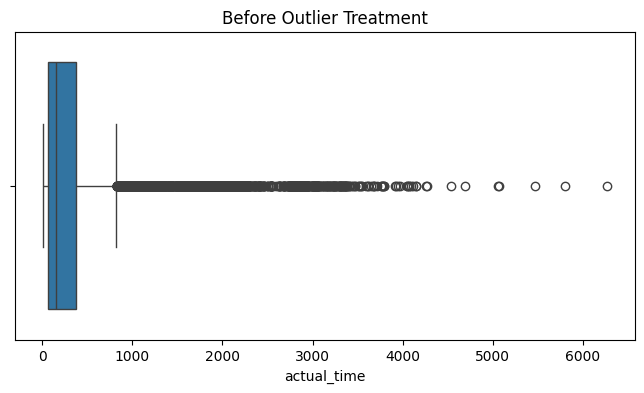

In [147]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df['actual_time']
)

plt.title('Before Outlier Treatment')

plt.show()

After Outlier Treatment

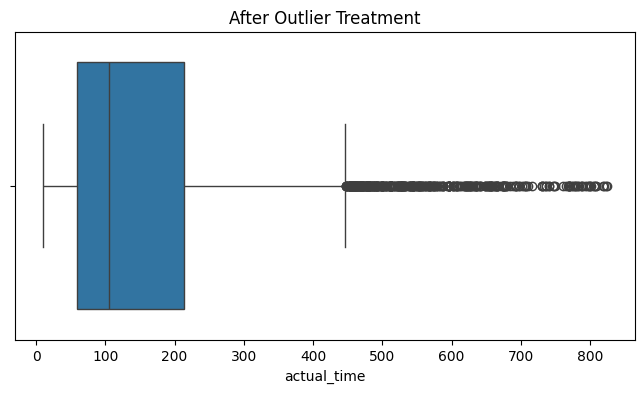

In [148]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=trip_df_clean['actual_time']
)

plt.title('After Outlier Treatment')

plt.show()

**Observation:**

After outlier treatment, the spread of extreme delivery duration values reduced significantly, resulting in a more compact and analytically stable distribution.

# Handling Categorical Variables

In [149]:
trip_df_encoded = pd.get_dummies(
    trip_df_clean,
    columns=['route_type'],
    drop_first=True
)

In [150]:
trip_df_encoded.columns

Index(['trip_uuid', 'actual_time', 'osrm_time', 'osrm_distance',
       'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
       'start_scan_to_end_scan', 'od_time_diff', 'trip_creation_time',
       'source_name', 'destination_name', 'source_state', 'destination_state',
       'source_city', 'destination_city', 'time_difference', 'delay_ratio',
       'actual_speed', 'osrm_speed', 'route_type_FTL'],
      dtype='object')

**Observation:**

The categorical route type feature was converted into numerical format using one-hot encoding, enabling its use in machine learning and statistical analysis.

# Feature Scaling

In [151]:
num_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'actual_speed',
    'osrm_speed',
    'delay_ratio'
]

In [152]:
from sklearn.preprocessing import StandardScaler

In [153]:
scaler = StandardScaler()

trip_df_encoded[num_cols] = scaler.fit_transform(
    trip_df_encoded[num_cols]
)

Scaled Numerical Features

In [154]:
trip_df_encoded[num_cols].head()

,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,actual_speed,osrm_speed,delay_ratio
1,-0.078503,0.057993,0.157129,-0.083239,-0.109554,0.050853,0.430143,0.733661,-0.283334
3,-0.726022,-0.936714,-0.839565,-0.719043,-0.919889,-0.854094,-0.976295,1.073215,0.650647
4,1.447792,0.977628,1.096698,1.459748,0.717318,0.931734,-0.455295,0.750527,0.130789
5,-0.710605,-0.786570,-0.711843,-0.711289,-0.804127,-0.738879,-0.296157,0.556887,-0.003081
6,-0.995822,-0.974250,-0.956272,-0.990422,-0.969501,-0.964667,-0.077417,-1.106421,-0.414363


**Observation:**

Numerical variables were standardized using StandardScaler to ensure consistent scaling across features and reduce the impact of differing numerical magnitudes.

In [155]:
trip_df_encoded.describe().T

,count,mean,min,25%,50%,75%,max,std
actual_time,11801.0,0.0,-1.103742,-0.726022,-0.371428,0.468805,5.171027,1.000042
osrm_time,11801.0,-0.0,-1.105627,-0.749033,-0.411208,0.545963,3.642692,1.000042
osrm_distance,11801.0,0.0,-1.00114,-0.721589,-0.464946,0.509451,2.924476,1.000042
segment_actual_time,11801.0,0.0,-1.098974,-0.726796,-0.370126,0.467274,5.204787,1.000042
segment_osrm_time,11801.0,0.0,-1.085263,-0.754514,-0.374153,0.518869,5.728163,1.000042
segment_osrm_distance,11801.0,0.0,-1.006113,-0.733127,-0.42159,0.556969,6.64172,1.000042
start_scan_to_end_scan,11801.0,290.017456,23.0,131.0,217.0,372.0,2920.0,236.240186
od_time_diff,11801.0,290.805765,23.461468,131.487092,217.998322,373.25304,2921.545709,236.504486
trip_creation_time,11801,2018-09-22 14:16:56.022492416,2018-09-12 00:00:22.886430,2018-09-17 04:27:17.199638016,2018-09-22 06:09:34.298350080,2018-09-27 22:23:45.342044928,2018-10-03 23:59:42.701692,NaN
time_difference,11801.0,88.273875,-32.0,28.0,57.0,119.0,762.0,92.955101


#Corridor Analysis

In [157]:
trip_df['corridor'] = (
    trip_df['source_state'] +
    ' to ' +
    trip_df['destination_state']
)

trip_df['corridor'].value_counts().head(5)

,count
corridor,
Maharashtra to Maharashtra,2453
Karnataka to Karnataka,2057
Tamil Nadu to Tamil Nadu,1021
Haryana to Haryana,949
Telangana to Telangana,689


**Observation:**

Certain interstate logistics corridors dominate shipment movement volumes, indicating concentrated delivery demand across major operational regions.

In [158]:
busiest = trip_df['corridor'].value_counts().idxmax()

busiest_data = trip_df[
    trip_df['corridor'] == busiest
]

print("Busiest Corridor:", busiest)

print(
    "Average Distance:",
    busiest_data['osrm_distance'].mean()
)

print(
    "Average Actual Time:",
    busiest_data['actual_time'].mean()
)

Busiest Corridor: Maharashtra to Maharashtra
Average Distance: 88.29726812066858
Average Actual Time: 185.14349775784754


**Observation:**

The busiest logistics corridor shows high shipment concentration and substantial operational delivery activity, making it a critical route for optimization and resource planning.

# Business Insights

• Actual delivery times are consistently higher than OSRM estimated delivery times, indicating real-world operational delays beyond route estimation models.

• Strong positive relationships exist between delivery distance and delivery duration, confirming that longer corridors naturally require more operational time.

• Delivery-related variables exhibit heavy right-skewness, indicating that while most trips operate within normal ranges, a small number of trips experience extreme delays.

• Significant statistical differences exist between actual operational metrics and segment-level aggregated metrics, suggesting variability across shipment segments.

• Outlier analysis revealed the presence of highly delayed trips, which may indicate operational bottlenecks, traffic disruptions, or exceptional logistics conditions.

• OSRM-based routing metrics show strong correlations with actual operational metrics, indicating that route estimation systems capture overall delivery trends reasonably well.

• Most delivery operations are concentrated within lower distance and lower delivery-duration ranges, suggesting that the majority of shipments occur within shorter corridors.

# Recommendations

• Improve route planning and traffic-aware scheduling to reduce the gap between estimated and actual delivery times.

• Monitor high-delay trips separately to identify recurring operational bottlenecks and improve delivery consistency.

• Recalibrate OSRM-based delivery estimates using historical operational data to improve delivery-time prediction accuracy.

• Focus operational optimization efforts on long-distance delivery corridors, as they contribute disproportionately to extreme delivery durations.

• Use segment-level operational analysis to identify inefficient shipment transitions and improve logistics coordination across delivery stages.

# Conclusion

The analysis successfully transformed raw shipment-segment data into meaningful trip-level operational insights through data cleaning, aggregation, feature engineering, visualization, hypothesis testing, and outlier treatment.

The study identified significant differences between estimated and actual logistics metrics, highlighting operational inefficiencies and opportunities for delivery optimization. The engineered features and processed dataset can further support forecasting models and operational decision-making for logistics management.